# Renee's EDA – Product Type vs. Average Price by Country/Currency
**Dataset:** Makeup API (clean_makeup.csv)  
**Research Question:** How does the average price of each makeup product type vary across countries/currencies?  
**Analyst:** Renee Jackson  
**Date:** May 2026

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', palette='muted')

df = pd.read_csv('../data/processed/clean_makeup.csv')

print(f'Shape: {df.shape}')
df.head()

Shape: (931, 9)


,id,brand,name,category,product_type,price,currency,tag_list,rating
0,1048,colourpop,Lippie Pencil,pencil,lip_liner,5.0,CAD,"['cruelty free', 'Vegan']",NaN
1,1047,colourpop,Blotted Lip,lipstick,lipstick,5.5,CAD,"['cruelty free', 'Vegan']",NaN
2,1046,colourpop,Lippie Stix,lipstick,lipstick,5.5,CAD,"['cruelty free', 'Vegan']",NaN
3,1045,colourpop,No Filter Foundation,liquid,foundation,12.0,CAD,"['cruelty free', 'Vegan']",NaN
4,1044,boosh,Lipstick,lipstick,lipstick,26.0,CAD,"['Chemical Free', 'Organic']",NaN


## 2. Data Overview

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 931 entries, 0 to 930
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            931 non-null    int64  
 1   brand         919 non-null    object 
 2   name          931 non-null    object 
 3   category      507 non-null    object 
 4   product_type  931 non-null    object 
 5   price         917 non-null    float64
 6   currency      368 non-null    object 
 7   tag_list      931 non-null    object 
 8   rating        340 non-null    float64
dtypes: float64(2), int64(1), object(6)
memory usage: 65.6+ KB


In [3]:
df.describe()

,id,price,rating
count,931.000000,917.000000,340.000000
mean,531.163265,16.508593,4.319118
std,311.054915,11.028035,0.675849
min,1.000000,0.000000,1.500000
25%,263.000000,8.990000,4.000000
50%,518.000000,13.990000,4.500000
75%,814.500000,22.000000,5.000000
max,1048.000000,77.000000,5.000000


## 3. Data Cleaning

Since we are comparing prices **within** each currency group (not converting to a common currency), we simply need to:
1. Ensure `price` is numeric
2. Remove rows with missing or zero prices — these cannot be analyzed
3. Check which currencies and product types are represented

Keeping prices in their local currency is intentional here. Converting to USD would introduce exchange rate effects that are separate from what we want to study — the pricing behavior of each product type in its local market.

In [4]:
df['price'] = pd.to_numeric(df['price'], errors='coerce')

df_clean = df[(df['price'].notna()) & (df['price'] > 0)].copy()

print(f'Rows before cleaning: {len(df)}')
print(f'Rows after removing null/zero prices: {len(df_clean)}')
print(f'Rows dropped: {len(df) - len(df_clean)}')

Rows before cleaning: 931
Rows after removing null/zero prices: 877
Rows dropped: 54


In [5]:
print('Currencies in dataset:')
print(df_clean['currency'].value_counts())
print()
print('Product types in dataset:')
print(df_clean['product_type'].value_counts())

Currencies in dataset:
currency
USD    250
GBP     71
CAD      7
Name: count, dtype: int64

Product types in dataset:
product_type
foundation     159
lipstick       145
eyeliner       143
mascara         85
blush           72
eyeshadow       72
bronzer         67
nail_polish     59
eyebrow         47
lip_liner       28
Name: count, dtype: int64


## 4. Univariate Analysis

Before comparing across groups, we explore each variable individually.

### 4a. Distribution of Product Types

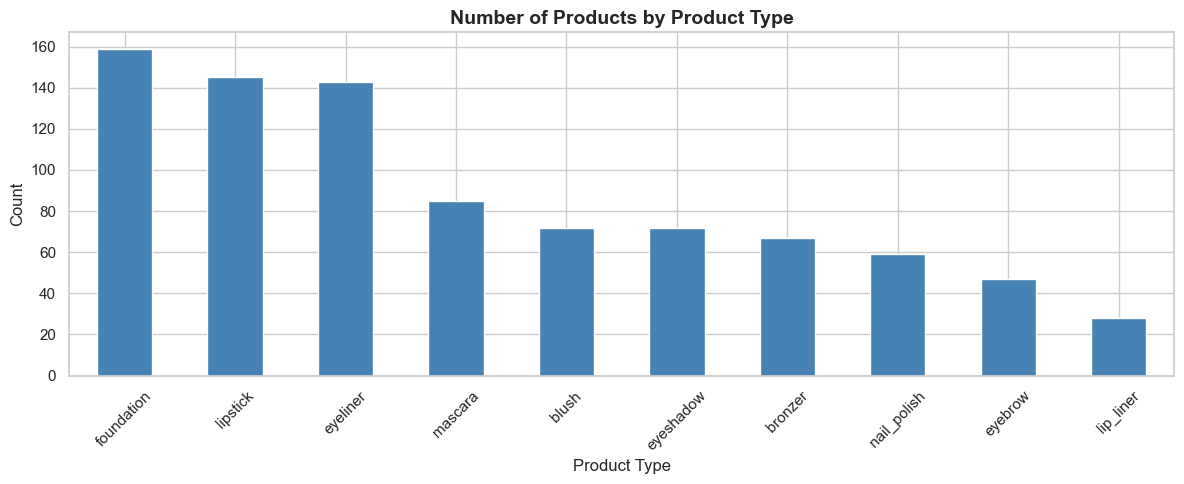

In [6]:
fig, ax = plt.subplots(figsize=(12, 5))
df_clean['product_type'].value_counts().plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Number of Products by Product Type', fontsize=14, fontweight='bold')
ax.set_xlabel('Product Type')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

**Observation:** Some product types appear far more frequently than others. Product types with very few entries may produce less reliable average price estimates when broken down further by currency.

### 4b. Distribution of Currency

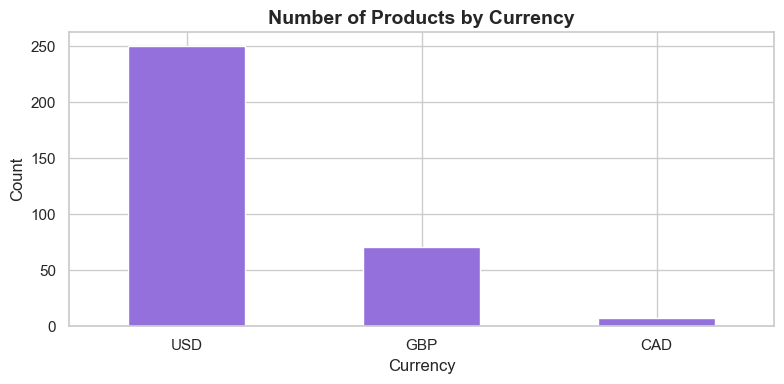

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
df_clean['currency'].value_counts().plot(kind='bar', ax=ax, color='mediumpurple', edgecolor='white')
ax.set_title('Number of Products by Currency', fontsize=14, fontweight='bold')
ax.set_xlabel('Currency')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

**Observation:** The dataset is likely dominated by one currency (e.g. USD). Currencies with very few products (CAD) will have limited statistical power when broken down by product type — we should note this as a limitation.

### 4c. Price Distribution per Currency

Since prices are in different currencies, we look at the price distribution **within each currency group** separately.

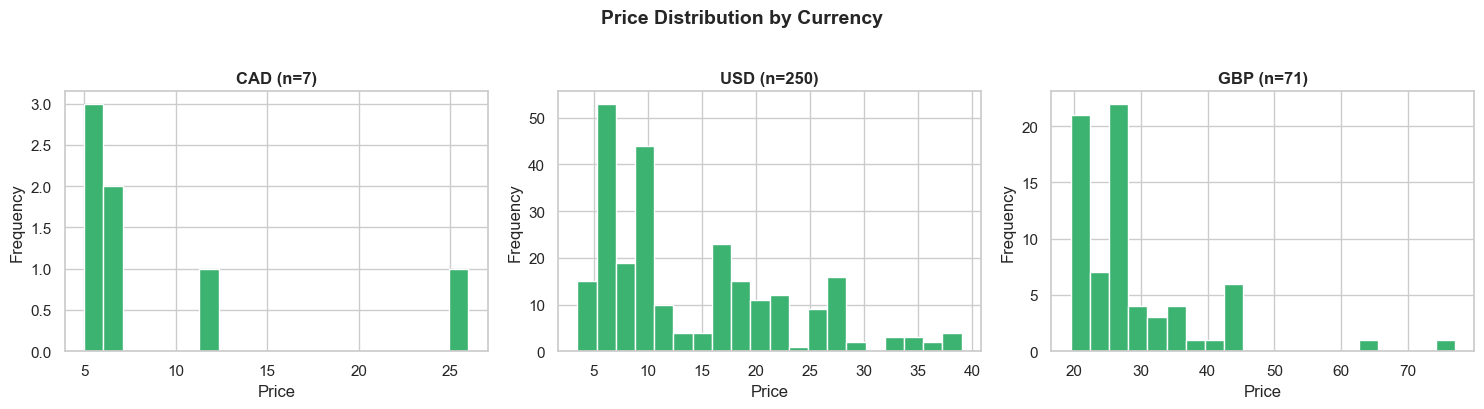

In [8]:
currencies = df_clean['currency'].dropna().unique()

fig, axes = plt.subplots(1, len(currencies), figsize=(5 * len(currencies), 4), sharey=False)

if len(currencies) == 1:
    axes = [axes]

for ax, currency in zip(axes, currencies):
    subset = df_clean[df_clean['currency'] == currency]['price']
    ax.hist(subset, bins=20, color='mediumseagreen', edgecolor='white')
    ax.set_title(f'{currency} (n={len(subset)})', fontsize=12, fontweight='bold')
    ax.set_xlabel('Price')
    ax.set_ylabel('Frequency')

plt.suptitle('Price Distribution by Currency', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Observation:

CAD (n=7) — Only 7 Canadian products. Most are priced between $5-$10 CAD, with a couple going up to $25. Very small sample so not very reliable.

USD (n=250) — The biggest group with 250 products. Most products cluster between $5-$15, with the frequency dropping off as price goes up. A few products go all the way to $40. This is your most reliable panel.

GBP (n=71) — 71 UK products. Most are priced between £20-£30, with some going up to £70. Notice the prices look higher in number but that's because £1 is worth more than $1 — so £20 is roughly $25.

Within each panel, you can see that most products in every market are budget-to-mid range, with a right skew of more expensive items. The right-skewed shape appears in all three markets.

Price distributions differ across currencies, which is expected since these represent different markets with different purchasing power and retail norms. This reinforces why I am comparing within each currency rather than converting and pooling all prices together.

## 5. Bivariate Analysis – Product Type vs. Average Price by Currency

Now we explore the core question: **within each currency/country, which product types are most expensive?**

In [9]:
# Average price grouped by product type AND currency
avg_price = (
    df_clean.groupby(['currency', 'product_type'])['price']
    .agg(avg_price='mean', count='count')
    .reset_index()
)
avg_price['avg_price'] = avg_price['avg_price'].round(2)

print('Average price by currency and product type:')
avg_price

Average price by currency and product type:


,currency,product_type,avg_price,count
0,CAD,foundation,8.53,3
1,CAD,lip_liner,5.00,1
2,CAD,lipstick,12.33,3
3,GBP,blush,31.12,4
4,GBP,bronzer,36.50,1
5,GBP,eyebrow,25.40,5
6,GBP,eyeliner,23.50,6
7,GBP,eyeshadow,38.50,10
8,GBP,foundation,31.78,9
9,GBP,lipstick,30.57,15


### 5a. Grouped Bar Chart – Average Price by Product Type, Colored by Currency

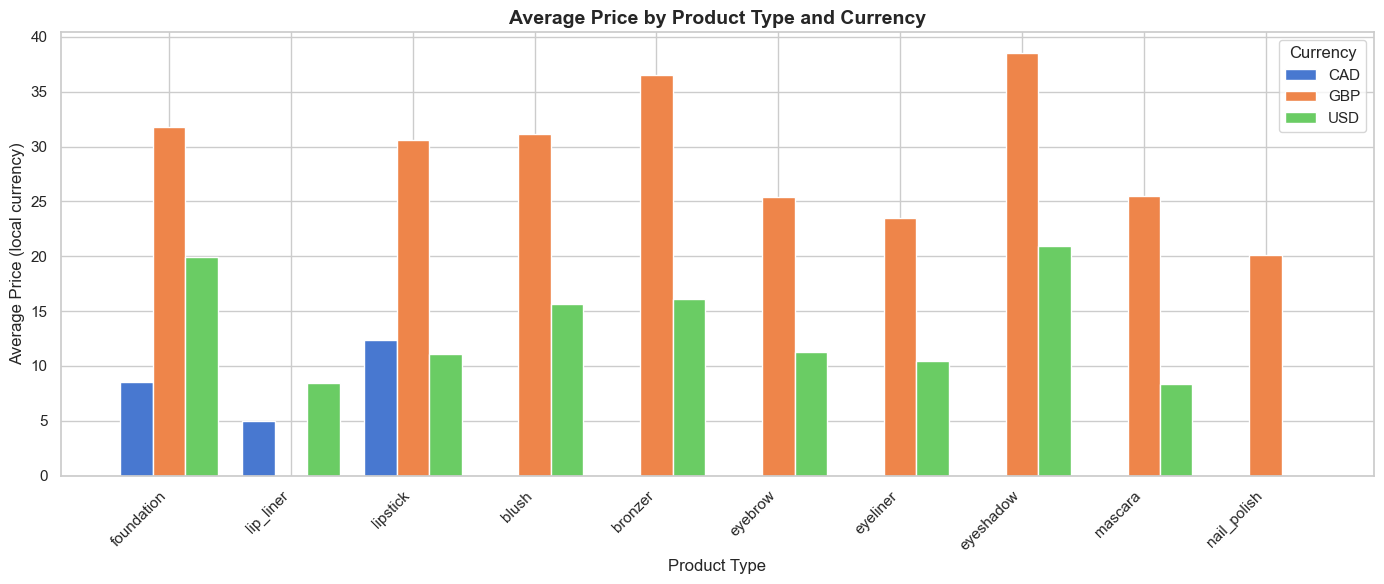

In [10]:
fig, ax = plt.subplots(figsize=(14, 6))

currencies_present = avg_price['currency'].unique()
product_types = avg_price['product_type'].unique()
x = range(len(product_types))
width = 0.8 / len(currencies_present)
colors = sns.color_palette('muted', len(currencies_present))

for i, (currency, color) in enumerate(zip(currencies_present, colors)):
    subset = avg_price[avg_price['currency'] == currency]
    # Align to product_types order
    prices = [subset.loc[subset['product_type'] == pt, 'avg_price'].values[0]
              if pt in subset['product_type'].values else 0
              for pt in product_types]
    offset = (i - len(currencies_present) / 2) * width + width / 2
    ax.bar([xi + offset for xi in x], prices, width=width,
           label=currency, color=color, edgecolor='white')

ax.set_title('Average Price by Product Type and Currency', fontsize=14, fontweight='bold')
ax.set_xlabel('Product Type', fontsize=12)
ax.set_ylabel('Average Price (local currency)', fontsize=12)
ax.set_xticks(list(x))
ax.set_xticklabels(product_types, rotation=45, ha='right')
ax.legend(title='Currency')
plt.tight_layout()
plt.show()

**Observation:** This chart shows a comparison of the average price of different product types across the 3 different countries/currencies. Note that bars for different currencies are not directly comparable in absolute terms (since £10 ≠ $10), but the **relative ranking** of product types within each currency shows us which categories are considered premium vs. budget in each market. Eyeshadow appears to be the most expensive makeup type across all countries/currencies. 

Here is a ranking list of the Top 3 per Country/Currency:

CAD(limited data set)

1. Lipstick
2. Foundation
3. Lip liner

GBP

1. Eyeshadow
2. Bronzer
3. Foundation

USD

1. Eyeshadow
2. Foundation
3. Bronzer

### 5b. Heatmap – Average Price by Product Type and Currency

A heatmap makes it easier to spot patterns across many product type / currency combinations at a glance.

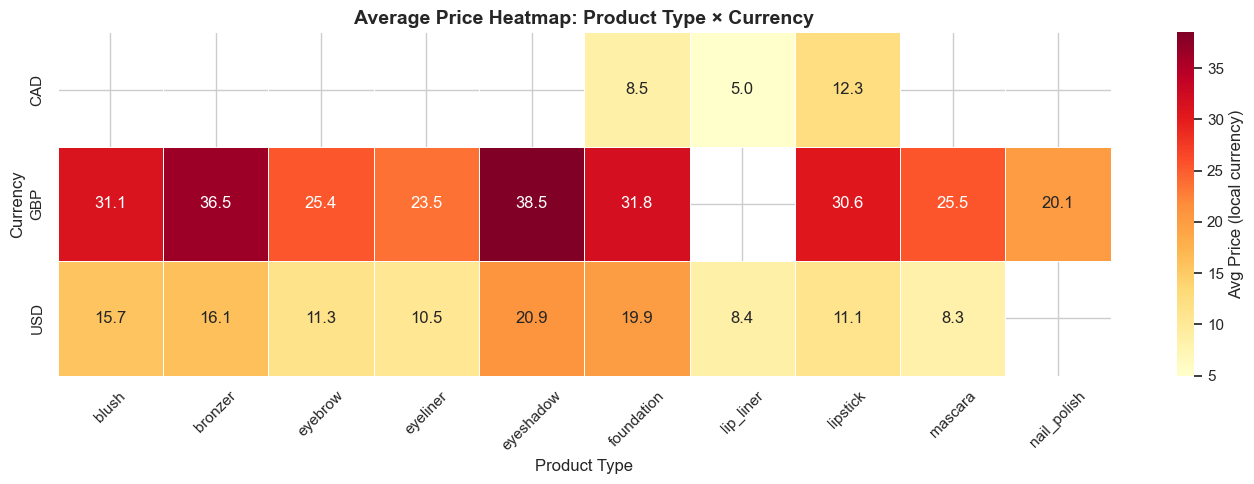

In [11]:
# Pivot for heatmap
heatmap_data = avg_price.pivot(index='currency', columns='product_type', values='avg_price')

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.1f',
    cmap='YlOrRd',
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'Avg Price (local currency)'}
)
ax.set_title('Average Price Heatmap: Product Type × Currency', fontsize=14, fontweight='bold')
ax.set_xlabel('Product Type', fontsize=12)
ax.set_ylabel('Currency', fontsize=12)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

**Observation:** The heatmap highlights which product type / currency combinations have the highest average prices (darker cells). Empty cells (NaN) indicate that no products of that type were listed in that currency, which is worth noting as a gap in the dataset.

### 5c. Faceted Bar Charts – One Panel per Currency

To see within-currency rankings clearly without cross-currency visual clutter, we plot one bar chart per currency.

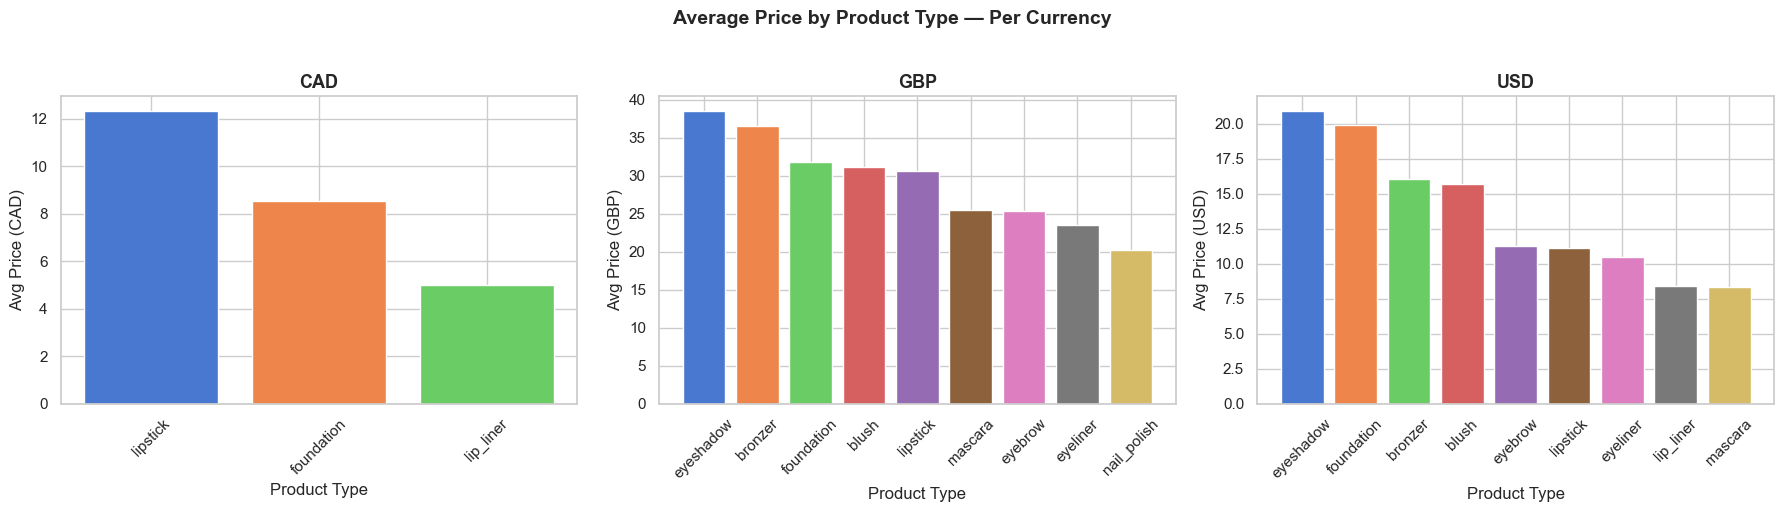

In [12]:
currencies_present = avg_price['currency'].unique()
n = len(currencies_present)
fig, axes = plt.subplots(1, n, figsize=(6 * n, 5), sharey=False)

if n == 1:
    axes = [axes]

for ax, currency in zip(axes, currencies_present):
    subset = avg_price[avg_price['currency'] == currency].sort_values('avg_price', ascending=False)
    ax.bar(subset['product_type'], subset['avg_price'],
           color=sns.color_palette('muted', len(subset)), edgecolor='white')
    ax.set_title(f'{currency}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Product Type')
    ax.set_ylabel(f'Avg Price ({currency})')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Average Price by Product Type — Per Currency', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Observation:** The faceted view lets us compare the **ranking** of product types within each market independently. If the same product type consistently ranks as most expensive across multiple currencies, that suggests it is a premium category globally, not just in one market.

## 6. Key Findings & Conclusions

1. **Within-currency pricing patterns:** By keeping prices in local currencies, we can see how each market ranks product types by cost — revealing genuine local pricing behavior rather than exchange rate artifacts.

2. **Data limitations:** Canada (CAD) have very few products, which makes their average prices less statistically reliable. 

3. **Missing combinations:** Not all product types are represented in every currency (CAD), meaning the dataset does not give us a complete cross-market picture for every category.

4. **Consistent premium categories:** Product types that rank as expensive across multiple currencies(Eyeshadow, Foundation & Bronzer) are likely globally positioned as more valuable or premium items, while those that are cheap in all markets represent accessible, everyday products. I thought it was interesting that in GBP, Bronzer is more expensive than foundation, and in USD, foundation is more expensive than bronzer.

**Next steps:** These insights from can be used in a price prediction model. 